# Perbandingan 3 Algoritma Clustering
Dataset: Web Page Phishing (`dataset_B_05_2020`)

Isi notebook:
1. K-Means (Euclidean)
2. K-Medians (Manhattan)
3. K-Means (Cosine Similarity)
4. **Perbandingan diagram batang**

Kode di bagian 1-3 adalah kode asli tanpa perubahan. Yang ditambahkan hanya sel bertanda `# [TAMBAHAN]`.

---
# 1. K-Means (Euclidean Distance)

Euclidean Distance

In [13]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import VarianceThreshold

import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("/content/drive/MyDrive/ML 2026/quiz/dataset_B_05_2020 (1).csv")

print("Shape dataset:", df.shape)
print("Jumlah data:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Shape dataset: (11430, 89)
Jumlah data: 11430
Jumlah kolom: 89


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
urls = df["url"].copy()
labels = df["status"].copy()

# Hanya fitur numerik
X = df.drop(columns=["url", "status"])
X = X.select_dtypes(include=np.number)

print("\nShape fitur numerik:", X.shape)
df.head()


Shape fitur numerik: (11430, 87)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [17]:
print("Total missing value:", X.isna().sum().sum())

X = X.fillna(X.median())


Total missing value: 0


In [18]:
selector = VarianceThreshold(threshold=0)

X_selected = selector.fit_transform(X)

selected_features = X.columns[
    selector.get_support()
]

X_selected = pd.DataFrame(
    X_selected,
    columns=selected_features
)

print("\nSetelah menghapus fitur konstan:")
print("Shape:", X_selected.shape)

print("Jumlah fitur:", len(selected_features))


Setelah menghapus fitur konstan:
Shape: (11430, 81)
Jumlah fitur: 81


In [19]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_selected)

print("\nSetelah StandardScaler:")
print("Shape:", X_scaled.shape)
df.head()


Setelah StandardScaler:
Shape: (11430, 81)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [20]:
print("BEFORE PREPROCESSING")
print(f"Bentuk data asli (df): {df.shape}")
# Menampilkan 3 baris awal dengan 5 kolom pertama dan 5 kolom terakhir
display(df.head(3))

print("AFTER PREPROCESSING")
print(f"Bentuk data siap klastering (X_scaled): {X_scaled.shape}")
# Mengubah array X_scaled kembali menjadi DataFrame untuk kemudahan visualisasi
df_after = pd.DataFrame(X_scaled, columns=selected_features)
display(df_after.head(3))

BEFORE PREPROCESSING
Bentuk data asli (df): (11430, 89)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing


AFTER PREPROCESSING
Bentuk data siap klastering (X_scaled): (11430, 81)


,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_eq,nb_underscore,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
0,-0.436327,-0.193964,-0.421020,0.379116,-0.477984,-0.142915,-0.387464,-0.197604,-0.293683,-0.295128,...,-0.377549,-1.860473,1.129194,-0.28037,-0.549299,-1.307594,-0.429340,6.978227,0.934264,0.320974
1,0.287067,0.177207,2.375182,-1.081136,-0.477984,-0.142915,-0.387464,-0.197604,-0.293683,-0.295128,...,-0.377549,0.537498,-0.885587,-0.28037,-0.510022,0.548471,-0.429340,-0.143303,0.934264,-0.467407
2,1.173224,2.682613,2.375182,1.109242,0.001174,-0.142915,2.356473,2.237556,2.711505,1.534217,...,-0.377549,0.537498,-0.885587,-0.28037,-0.587348,-0.018839,2.491612,-0.143303,0.934264,-1.255788


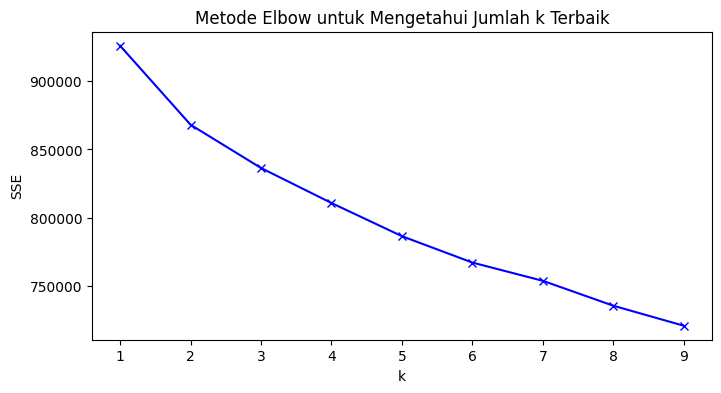

In [21]:
# Implementasi Metode Elbow

# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1,10)

# Cek nilai SSE setiap k
for k in K:
 kmeanModel = KMeans(n_clusters=k, random_state=42, n_init=10)
 kmeanModel.fit(X_scaled)
 sse.append(kmeanModel.inertia_)


# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")

plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

In [22]:
!pip install kneed

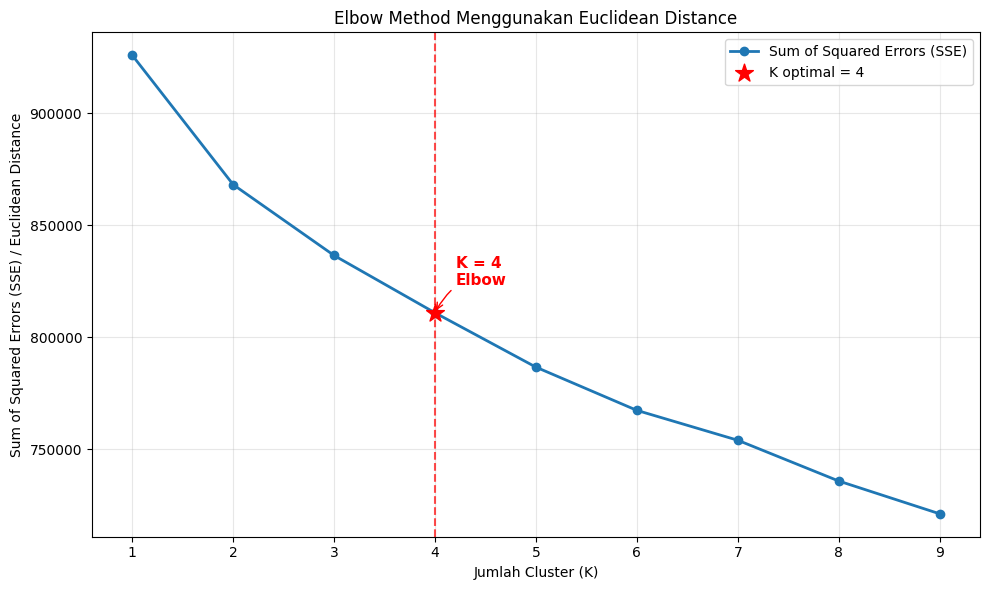

In [23]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from kneed import KneeLocator

# 1. Menghitung SSE untuk K 1 hingga 9
sse = []
K = range(1, 10)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeanModel.fit(X_scaled) # Pastikan data Anda (X_scaled) sudah diload dan diskalakan
    sse.append(kmeanModel.inertia_)

# 2. Mencari K optimal dengan KneeLocator
kl = KneeLocator(K, sse, curve="convex", direction="decreasing")
optimal_k = kl.elbow

# Mencari indeks dari optimal_k di dalam list K untuk mendapatkan nilai Y (SSE) yang tepat
optimal_index = list(K).index(optimal_k)

# 3. Visualisasi dengan gaya kustom
plt.figure(figsize=(10, 6))

plt.plot(
    K,
    sse,
    marker="o",
    linewidth=2,
    color="tab:blue",
    label="Sum of Squared Errors (SSE)"
)

if optimal_k is not None:
    # Titik K optimal
    plt.scatter(
        optimal_k,
        sse[optimal_index],
        s=180,
        color="red",
        marker="*",
        zorder=5,
        label=f"K optimal = {optimal_k}"
    )

    # Garis vertikal
    plt.axvline(
        optimal_k,
        color="red",
        linestyle="--",
        alpha=0.7
    )

    # Label Anotasi
    plt.annotate(
        f"K = {optimal_k}\nElbow",
        xy=(
            optimal_k,
            sse[optimal_index]
        ),
        xytext=(15, 20), # Disesuaikan sedikit agar teks tidak tertabrak garis
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
        color="red",
        arrowprops=dict(arrowstyle="->", color="red", connectionstyle="arc3,rad=.2")
    )

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Sum of Squared Errors (SSE) / Euclidean Distance")
plt.title("Elbow Method Menggunakan Euclidean Distance")

plt.xticks(list(K))
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=925829.9999999907
k=2; SSE=868078.5870757764
k=3; SSE=836455.3028093267
k=4; SSE=810859.5471781332
k=5; SSE=786607.5986408117
k=6; SSE=767312.1744230196
k=7; SSE=753974.1107965728
k=8; SSE=735774.0449128747
k=9; SSE=721144.2111806673


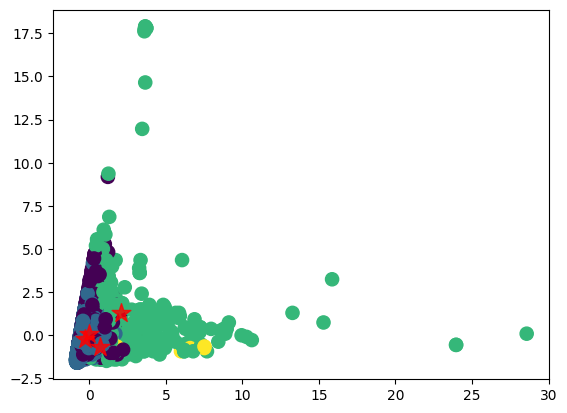

In [25]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)
y_kmeans = kmeans.predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, s=90, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.8, marker='*')

Menghitung Silhouette Score...
Untuk k=2, Silhouette Score = 0.3323
Untuk k=3, Silhouette Score = 0.0648
Untuk k=4, Silhouette Score = 0.0785
Untuk k=5, Silhouette Score = 0.0611
Untuk k=6, Silhouette Score = 0.0682
Untuk k=7, Silhouette Score = 0.0726
Untuk k=8, Silhouette Score = 0.0747
Untuk k=9, Silhouette Score = 0.0387


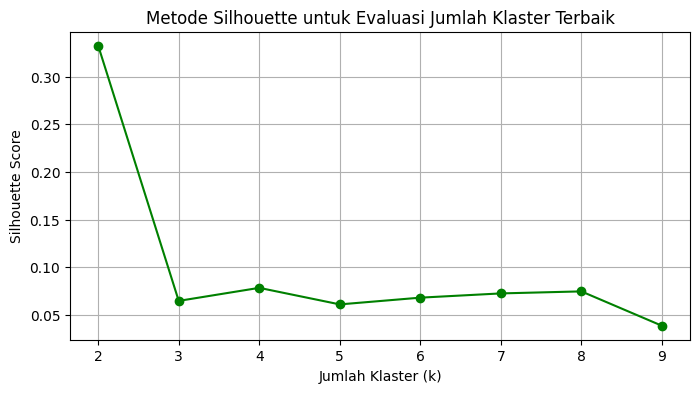

In [26]:
sil_scores = []
K_sil = range(2, 10) # Range k=2 hingga k=9

print("Menghitung Silhouette Score...")
for k in K_sil:
    # Inisialisasi dan latih model
    kmeans_sil = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_sil.fit_predict(X_scaled)

    # Hitung skor (tambahkan parameter sample_size=10000 jika data Anda yang 783k dipakai lagi)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

    print(f"Untuk k={k}, Silhouette Score = {score:.4f}")

# Memvisualisasikan hasil
plt.figure(figsize=(8, 4))
plt.plot(K_sil, sil_scores, "go-")
plt.xlabel("Jumlah Klaster (k)")
plt.ylabel("Silhouette Score")
plt.title("Metode Silhouette untuk Evaluasi Jumlah Klaster Terbaik")
plt.grid(True)
plt.show()

In [27]:
# [TAMBAHAN] Fungsi pengukur waktu komputasi & penggunaan memori (dipakai ketiga algoritma)
import time, os, gc, threading, tracemalloc
import psutil

def ukur_kinerja(fungsi, interval=0.005):
    """Menjalankan fungsi() dua kali:
    - Run 1: waktu komputasi (perf_counter) + puncak RSS proses lewat thread pemantau
    - Run 2: puncak alokasi Python/NumPy lewat tracemalloc
      (dipisah karena tracemalloc memperlambat eksekusi dan akan merusak pengukuran waktu)
    Mengembalikan (hasil, dict metrik).
    """
    proc = psutil.Process(os.getpid())

    # Run 1: waktu + RSS
    gc.collect()
    rss_awal = proc.memory_info().rss
    puncak = [rss_awal]
    stop = threading.Event()

    def pantau():
        while not stop.is_set():
            puncak[0] = max(puncak[0], proc.memory_info().rss)
            time.sleep(interval)

    th = threading.Thread(target=pantau, daemon=True)
    th.start()
    mulai = time.perf_counter()
    hasil = fungsi()
    waktu = time.perf_counter() - mulai
    puncak[0] = max(puncak[0], proc.memory_info().rss)
    stop.set(); th.join()

    # Run 2: tracemalloc
    gc.collect()
    tracemalloc.start()
    fungsi()
    _, puncak_tm = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return hasil, {
        "waktu_detik": waktu,
        "mem_rss_mib": (puncak[0] - rss_awal) / 1024**2,   # kenaikan puncak RSS selama fit
        "mem_tracemalloc_mib": puncak_tm / 1024**2,        # puncak alokasi Python/NumPy
    }

In [28]:
# [TAMBAHAN] Ukur waktu & memori: K-Means (Euclidean), fit final pada K optimal
def _fit_euclid():
    return KMeans(n_clusters=optimal_k, random_state=42, n_init=10).fit_predict(X_scaled)

_, ukur_euclid = ukur_kinerja(_fit_euclid)
print(f"K-Means Euclidean | waktu = {ukur_euclid['waktu_detik']:.3f} detik | "
      f"RSS = {ukur_euclid['mem_rss_mib']:.1f} MiB | tracemalloc = {ukur_euclid['mem_tracemalloc_mib']:.1f} MiB")

K-Means Euclidean | waktu = 1.362 detik | RSS = 0.0 MiB | tracemalloc = 14.2 MiB


In [29]:
# [TAMBAHAN] simpan hasil K-Means Euclidean untuk perbandingan
hasil_euclid = {
    "nama": "K-Means\n(Euclidean)",
    "K": optimal_k,
    "labels": np.array(y_kmeans).copy(),
    "silhouette_native": silhouette_score(X_scaled, y_kmeans),   # metric euclidean
    "total_cluster": len(np.unique(y_kmeans)),
    **ukur_euclid,                                               # waktu_detik, mem_rss_mib, mem_tracemalloc_mib
}
print("Tersimpan: K =", hasil_euclid["K"], "| Silhouette =", round(hasil_euclid["silhouette_native"], 4))

Tersimpan: K = 4 | Silhouette = 0.0785


---
# 2. K-Medians (Manhattan Distance)

# K-Medians Clustering (Jarak Manhattan)
Dataset: Web Page Phishing (Hannousse & Yahiouche, 2021)

Berbeda dengan `sklearn.cluster.KMeans` (Euclidean + centroid **mean**), di sini:
- **Penugasan cluster** memakai jarak **Manhattan (L1)**
- **Centroid** dihitung dengan **median** tiap fitur (minimizer jumlah jarak L1)
- **Silhouette** juga dihitung dengan `metric="manhattan"`

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.metrics import (
    pairwise_distances, silhouette_score,
    adjusted_rand_score, normalized_mutual_info_score
)

RANDOM_STATE = 42

## 1. Load data

In [31]:
FILE = "/content/drive/MyDrive/ML 2026/quiz/dataset_B_05_2020 (1).csv"

df = pd.read_csv(FILE)
print("Shape dataset:", df.shape)

y_true = df["status"].copy()          # label asli (TIDAK dipakai saat clustering)
X = df.drop(columns=["url", "status"]).select_dtypes(include=np.number)
print("Shape fitur numerik:", X.shape)
print("Missing value:", X.isna().sum().sum())

Shape dataset: (11430, 89)
Shape fitur numerik: (11430, 87)
Missing value: 0


## 2. Preprocessing

In [32]:
X = X.fillna(X.median())

selector = VarianceThreshold(threshold=0)
X_sel = selector.fit_transform(X)
selected_features = X.columns[selector.get_support()]
print("Fitur dihapus (konstan):", list(X.columns[~selector.get_support()]))

X_scaled = StandardScaler().fit_transform(X_sel)
print("Shape setelah scaling:", X_scaled.shape)

Fitur dihapus (konstan): ['nb_or', 'ratio_nullHyperlinks', 'ratio_intRedirection', 'ratio_intErrors', 'submit_email', 'sfh']
Shape setelah scaling: (11430, 81)


## 3. Implementasi K-Medians (Manhattan)

Langkah algoritma:
1. **Inisialisasi** centroid dengan seeding mirip k-means++ (probabilitas ∝ jarak Manhattan ke centroid terdekat)
2. **Assignment**: tiap titik ke centroid dengan jarak Manhattan terkecil
3. **Update**: centroid baru = **median** per fitur anggota cluster
4. Ulangi sampai centroid tidak berubah / `max_iter`
5. Jalankan `n_init` kali dengan seed berbeda, ambil yang **total jarak Manhattan** terkecil

Objektif: $J=\sum_{i}\sum_{j}\lVert x_i-\mu_{c(i)}\rVert_1$ (turun monoton di tiap iterasi).

In [33]:
def manhattan_to_centroids(X, C):
    return pairwise_distances(X, C, metric="manhattan")


def init_centroids_pp(X, k, rng):
    """Seeding ala k-means++ memakai jarak Manhattan."""
    n = X.shape[0]
    centers = [X[rng.integers(n)]]
    d = manhattan_to_centroids(X, np.array(centers)).min(axis=1)
    for _ in range(1, k):
        probs = d / d.sum()
        centers.append(X[rng.choice(n, p=probs)])
        d = np.minimum(d, manhattan_to_centroids(X, np.array(centers[-1:])).ravel())
    return np.array(centers)


def kmedians_single(X, k, max_iter=300, tol=1e-6, rng=None):
    rng = rng or np.random.default_rng(RANDOM_STATE)
    C = init_centroids_pp(X, k, rng)

    for it in range(max_iter):
        D = manhattan_to_centroids(X, C)
        labels = D.argmin(axis=1)

        C_new = C.copy()
        for j in range(k):
            members = X[labels == j]
            if len(members) > 0:
                C_new[j] = np.median(members, axis=0)      # centroid = MEDIAN
            else:
                # cluster kosong -> pindahkan ke titik terjauh dari centroid-nya
                far = D[np.arange(len(X)), labels].argmax()
                C_new[j] = X[far]

        shift = np.abs(C_new - C).sum()
        C = C_new
        if shift < tol:
            break

    D = manhattan_to_centroids(X, C)
    labels = D.argmin(axis=1)
    cost = D[np.arange(len(X)), labels].sum()
    return labels, C, cost, it + 1


def kmedians(X, k, n_init=10, max_iter=300, seed=RANDOM_STATE):
    best = None
    for s in range(n_init):
        rng = np.random.default_rng(seed + s)
        res = kmedians_single(X, k, max_iter=max_iter, rng=rng)
        if best is None or res[2] < best[2]:
            best = res
    return best   # labels, centroids, cost, n_iter

In [34]:
K_range = list(range(2, 11))
costs, sils, models = [], [], {}

for k in K_range:
    labels_k, cent_k, cost_k, n_it = kmedians(X_scaled, k, n_init=10)

    # Silhouette dengan jarak Manhattan
    sil_k = silhouette_score(
        X_scaled, labels_k, metric="manhattan",
    )

    costs.append(cost_k); sils.append(sil_k); models[k] = (labels_k, cent_k)
    print(f"K={k:2d} | Total Manhattan={cost_k:12.2f} | Silhouette(L1)={sil_k:.4f} | iter={n_it}")

print("\nCek monoton turun:", all(np.diff(costs) <= 1e-6))

K= 2 | Total Manhattan=   342517.12 | Silhouette(L1)=0.1001 | iter=9
K= 3 | Total Manhattan=   325824.02 | Silhouette(L1)=0.1174 | iter=12
K= 4 | Total Manhattan=   315416.00 | Silhouette(L1)=0.1130 | iter=27
K= 5 | Total Manhattan=   305458.54 | Silhouette(L1)=0.0505 | iter=31
K= 6 | Total Manhattan=   298057.24 | Silhouette(L1)=0.0700 | iter=16
K= 7 | Total Manhattan=   289579.77 | Silhouette(L1)=0.0759 | iter=13
K= 8 | Total Manhattan=   287255.61 | Silhouette(L1)=0.0657 | iter=17
K= 9 | Total Manhattan=   284391.07 | Silhouette(L1)=0.0696 | iter=19
K=10 | Total Manhattan=   280960.09 | Silhouette(L1)=0.0772 | iter=20

Cek monoton turun: True


K optimal (Elbow)      : 7
K terbaik (Silhouette) : 3


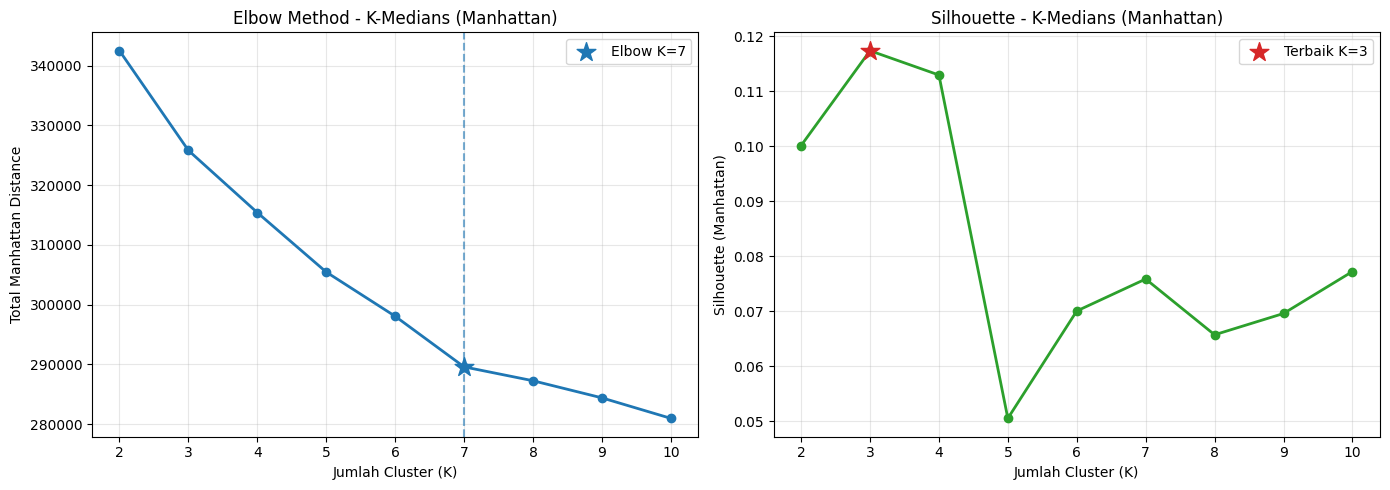

In [35]:
x = np.array(K_range, dtype=float)
y = np.array(costs, dtype=float)
xn = (x - x.min()) / (x.max() - x.min())
yn = (y - y.min()) / (y.max() - y.min())

# garis dari (0,1) ke (1,0): x + y - 1 = 0
dist_line = np.abs(xn + yn - 1) / np.sqrt(2)

optimal_k = K_range[int(np.argmax(dist_line))]
best_sil_k = K_range[int(np.argmax(sils))]
print("K optimal (Elbow)      :", optimal_k)
print("K terbaik (Silhouette) :", best_sil_k)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(K_range, costs, marker="o", lw=2)
ax[0].scatter(optimal_k, costs[K_range.index(optimal_k)], s=200, marker="*", zorder=5,
              label=f"Elbow K={optimal_k}")
ax[0].axvline(optimal_k, ls="--", alpha=.6)
ax[0].set(xlabel="Jumlah Cluster (K)", ylabel="Total Manhattan Distance",
          title="Elbow Method - K-Medians (Manhattan)")
ax[0].set_xticks(K_range); ax[0].grid(alpha=.3); ax[0].legend()

ax[1].plot(K_range, sils, marker="o", lw=2, color="tab:green")
ax[1].scatter(best_sil_k, max(sils), s=200, marker="*", zorder=5, color="tab:red",
              label=f"Terbaik K={best_sil_k}")
ax[1].set(xlabel="Jumlah Cluster (K)", ylabel="Silhouette (Manhattan)",
          title="Silhouette - K-Medians (Manhattan)")
ax[1].set_xticks(K_range); ax[1].grid(alpha=.3); ax[1].legend()

plt.tight_layout(); plt.show()

In [36]:
K_FINAL = optimal_k

cluster_labels, centroids, final_cost, n_iter = kmedians(X_scaled, K_FINAL, n_init=20)

df_clustered = df.copy()
df_clustered["cluster"] = cluster_labels

print(f"K-Medians (Manhattan) selesai | K={K_FINAL} | iter={n_iter} | total L1={final_cost:.2f}")
print("\nJumlah data per cluster:")
print(df_clustered["cluster"].value_counts().sort_index())

K-Medians (Manhattan) selesai | K=7 | iter=13 | total L1=289579.77

Jumlah data per cluster:
cluster
0     902
1    2410
2    1537
3     380
4    1962
5    2135
6    2104
Name: count, dtype: int64


In [37]:
ct = pd.crosstab(df_clustered["cluster"], y_true)
print(ct, "\n")


sil_full = silhouette_score(X_scaled, cluster_labels, metric="manhattan")

print(f"Silhouette (Manhattan): {sil_full:.4f}")


status   legitimate  phishing
cluster                      
0                17       885
1              2137       273
2               361      1176
3                 0       380
4              1900        62
5               793      1342
6               507      1597 

Silhouette (Manhattan): 0.0759


## 8. Visualisasi (PCA 2D)

Explained variance ratio: [0.10140136 0.05367566] | total: 0.1550770197495659


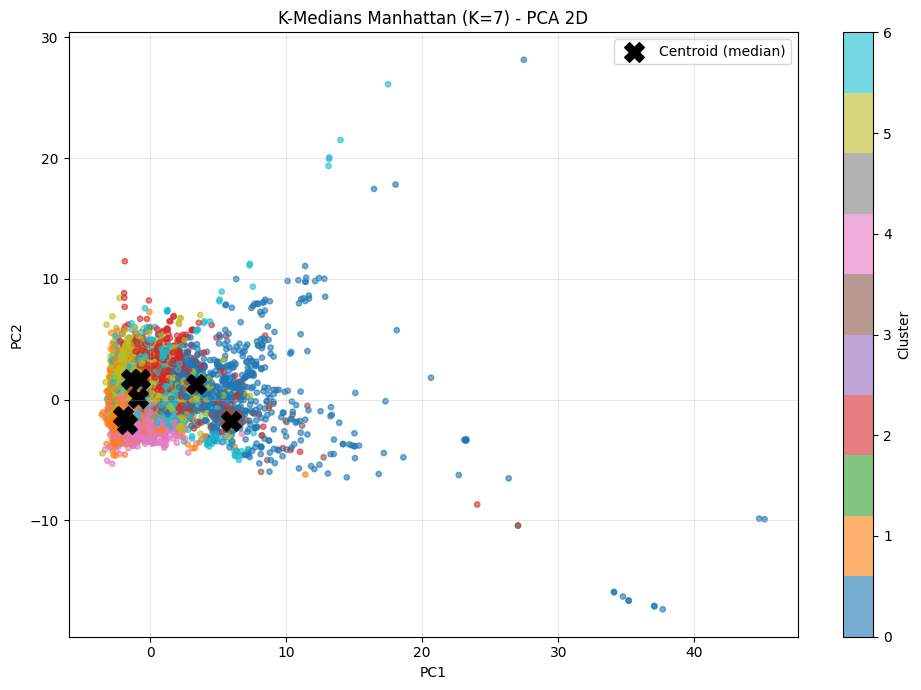

In [38]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_scaled)
C_2d = pca.transform(centroids)
print("Explained variance ratio:", pca.explained_variance_ratio_, "| total:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(10, 7))
sc = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, cmap="tab10", s=15, alpha=.6)
plt.scatter(C_2d[:, 0], C_2d[:, 1], c="black", marker="X", s=200, label="Centroid (median)")
plt.colorbar(sc, label="Cluster")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"K-Medians Manhattan (K={K_FINAL}) - PCA 2D")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## Catatan untuk laporan
- Rujukan K-Medians / L1: Bradley, Mangasarian & Street (1997); Kaufman & Rousseeuw (1990); Aggarwal et al. (2001).
- Rujukan Elbow & Kneedle: Thorndike (1953); Satopää et al. (2011). Silhouette: Rousseeuw (1987).
- Bila Elbow dan Silhouette tidak sepakat, jelaskan trade-off-nya di pembahasan. Silhouette yang rendah menandakan struktur cluster lemah pada data ini.

In [39]:
# [TAMBAHAN] Ukur waktu & memori: K-Medians (Manhattan), fit final (n_init=20 seperti sel final di atas)
def _fit_manhattan():
    return kmedians(X_scaled, K_FINAL, n_init=20)

_, ukur_manhattan = ukur_kinerja(_fit_manhattan)
print(f"K-Medians Manhattan | waktu = {ukur_manhattan['waktu_detik']:.3f} detik | "
      f"RSS = {ukur_manhattan['mem_rss_mib']:.1f} MiB | tracemalloc = {ukur_manhattan['mem_tracemalloc_mib']:.1f} MiB")

K-Medians Manhattan | waktu = 14.130 detik | RSS = 4.7 MiB | tracemalloc = 10.9 MiB


In [40]:
# [TAMBAHAN] simpan hasil K-Medians Manhattan untuk perbandingan
hasil_manhattan = {
    "nama": "K-Medians\n(Manhattan)",
    "K": K_FINAL,
    "labels": np.array(cluster_labels).copy(),
    "silhouette_native": sil_full,                                 # metric manhattan
    "total_cluster": len(np.unique(cluster_labels)),
    **ukur_manhattan,                                              # waktu_detik, mem_rss_mib, mem_tracemalloc_mib
}
print("Tersimpan: K =", hasil_manhattan["K"], "| Silhouette =", round(hasil_manhattan["silhouette_native"], 4))

Tersimpan: K = 7 | Silhouette = 0.0759


---
# 3. K-Means (Cosine Similarity)

In [41]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold

In [43]:
FILE = "/content/drive/MyDrive/ML 2026/quiz/dataset_B_05_2020 (1).csv"

df = pd.read_csv(FILE)

print("Shape dataset:", df.shape)
print("Jumlah data:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Shape dataset: (11430, 89)
Jumlah data: 11430
Jumlah kolom: 89


In [44]:
urls = df["url"].copy()
labels = df["status"].copy()

# Hanya fitur numerik
X = df.drop(columns=["url", "status"])
X = X.select_dtypes(include=np.number)

print("\nShape fitur numerik:", X.shape)
df.head()


Shape fitur numerik: (11430, 87)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [45]:

print("Total missing value:", X.isna().sum().sum())

X = X.fillna(X.median())


Total missing value: 0


In [46]:
selector = VarianceThreshold(threshold=0)

X_selected = selector.fit_transform(X)

selected_features = X.columns[
    selector.get_support()
]

X_selected = pd.DataFrame(
    X_selected,
    columns=selected_features
)

print("\nSetelah menghapus fitur konstan:")
print("Shape:", X_selected.shape)

print("Jumlah fitur:", len(selected_features))



Setelah menghapus fitur konstan:
Shape: (11430, 81)
Jumlah fitur: 81


In [47]:
removed_features = X.columns[
    ~selector.get_support()
]

print("\nFitur yang dihapus karena konstan:")
for feature in removed_features:
    print("-", feature)

print("\nJumlah fitur dihapus:", len(removed_features))


Fitur yang dihapus karena konstan:
- nb_or
- ratio_nullHyperlinks
- ratio_intRedirection
- ratio_intErrors
- submit_email
- sfh

Jumlah fitur dihapus: 6


In [48]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_selected)

print("\nSetelah StandardScaler:")
print("Shape:", X_scaled.shape)
df.head()


Setelah StandardScaler:
Shape: (11430, 81)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [49]:
from sklearn.preprocessing import normalize

X_cosine = normalize(
    X_scaled,
    norm="l2"
)

print("Shape:", X_cosine.shape)

Shape: (11430, 81)


In [50]:
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

K_range = range(2, 11)

cosine_similarity_scores = []

for k in K_range:

    print(f"Menjalankan K-Means untuk K={k}...")

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_cosine)

    # Cosine similarity data terhadap seluruh centroid
    similarities = cosine_similarity(
        X_cosine,
        kmeans.cluster_centers_
    )

    # Ambil similarity terhadap centroid cluster masing-masing data
    assigned_similarity = similarities[
        np.arange(len(X_cosine)),
        labels
    ]

    # Rata-rata similarity
    mean_similarity = assigned_similarity.mean()

    cosine_similarity_scores.append(
        mean_similarity
    )

    print(
        f"K={k} | "
        f"Mean Cosine Similarity={mean_similarity:.4f}"
    )

Menjalankan K-Means untuk K=2...
K=2 | Mean Cosine Similarity=0.2654
Menjalankan K-Means untuk K=3...
K=3 | Mean Cosine Similarity=0.3461
Menjalankan K-Means untuk K=4...
K=4 | Mean Cosine Similarity=0.3912
Menjalankan K-Means untuk K=5...
K=5 | Mean Cosine Similarity=0.4255
Menjalankan K-Means untuk K=6...
K=6 | Mean Cosine Similarity=0.4482
Menjalankan K-Means untuk K=7...
K=7 | Mean Cosine Similarity=0.4630
Menjalankan K-Means untuk K=8...
K=8 | Mean Cosine Similarity=0.4763
Menjalankan K-Means untuk K=9...
K=9 | Mean Cosine Similarity=0.4871
Menjalankan K-Means untuk K=10...
K=10 | Mean Cosine Similarity=0.4991


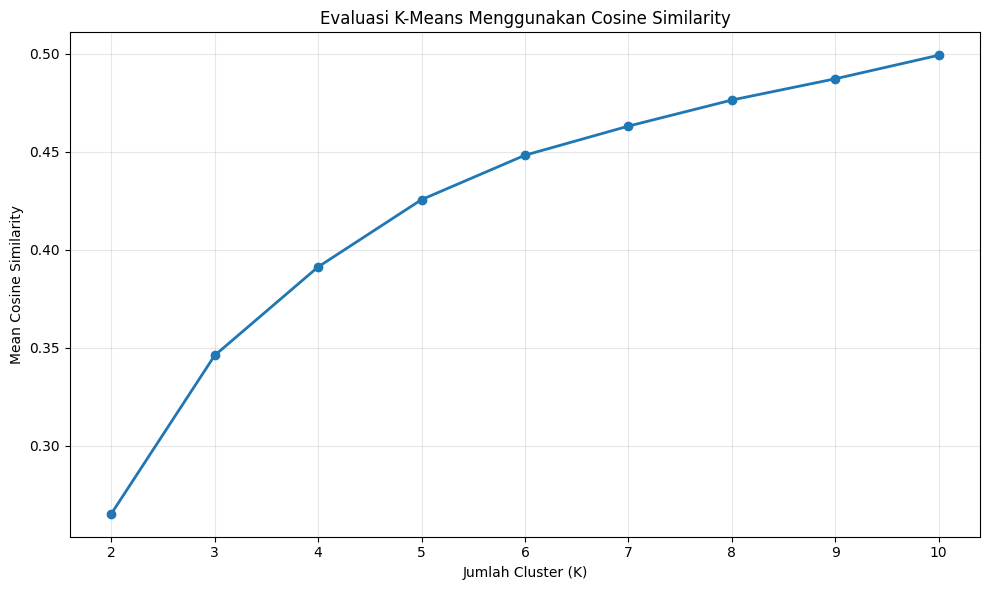

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    cosine_similarity_scores,
    marker="o",
    linewidth=2
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Mean Cosine Similarity")
plt.title("Evaluasi K-Means Menggunakan Cosine Similarity")

plt.xticks(list(K_range))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

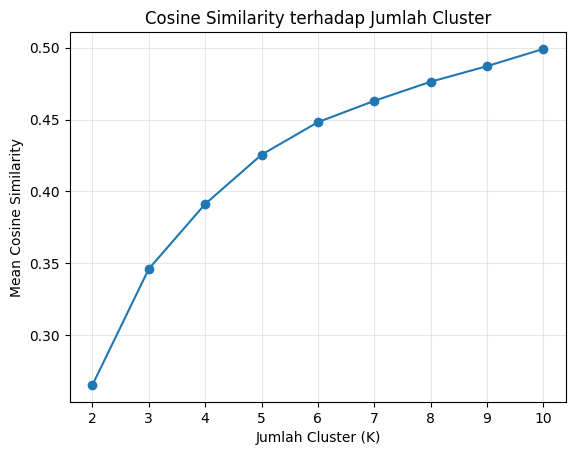

In [52]:
plt.plot(
    K_range,
    cosine_similarity_scores,
    marker="o"
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Mean Cosine Similarity")
plt.title("Cosine Similarity terhadap Jumlah Cluster")

plt.xticks(list(K_range))
plt.grid(alpha=0.3)

plt.show()

In [53]:
# [TAMBAHAN] variabel ini dipakai plot elbow di bawah tetapi tidak didefinisikan di notebook asli.
# Nilainya disamakan dengan K_OPTIMAL = 3 yang dipakai notebook asli.
optimal_k_cosine = 3
optimal_index = list(K_range).index(optimal_k_cosine)

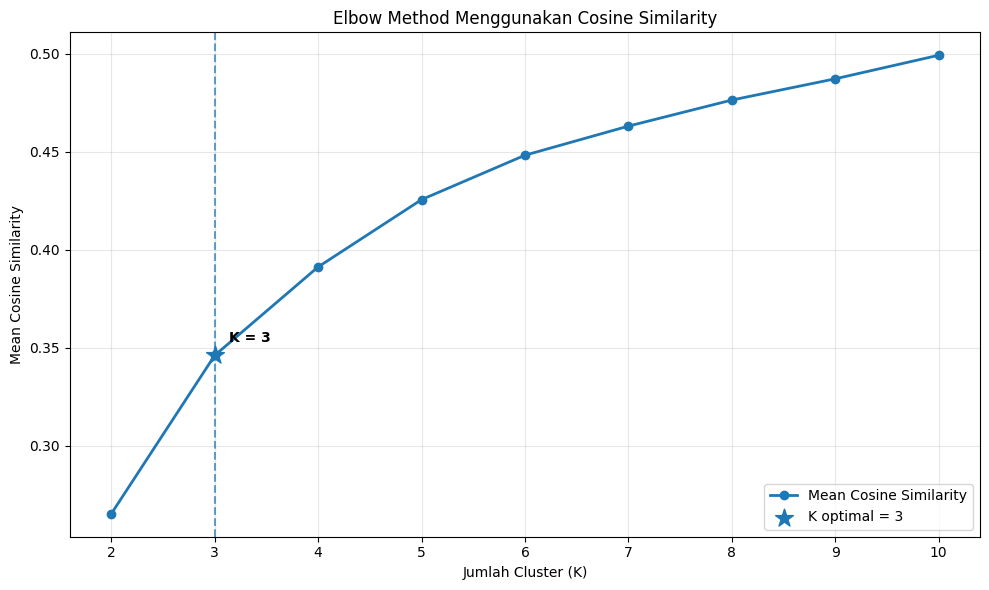

In [54]:
plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    cosine_similarity_scores,
    marker="o",
    linewidth=2,
    label="Mean Cosine Similarity"
)

plt.scatter(
    optimal_k_cosine,
    cosine_similarity_scores[optimal_index],
    s=180,
    marker="*",
    zorder=5,
    label=f"K optimal = {optimal_k_cosine}"
)

plt.axvline(
    optimal_k_cosine,
    linestyle="--",
    alpha=0.7
)

plt.annotate(
    f"K = {optimal_k_cosine}",
    xy=(
        optimal_k_cosine,
        cosine_similarity_scores[optimal_index]
    ),
    xytext=(10, 10),
    textcoords="offset points",
    fontweight="bold"
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Mean Cosine Similarity")
plt.title("Elbow Method Menggunakan Cosine Similarity")

plt.xticks(list(K_range))
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [55]:
K_OPTIMAL = 3

kmeans_final = KMeans(
    n_clusters=K_OPTIMAL,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_cosine)

print("K-Means selesai.")
print("K =", K_OPTIMAL)

print("\nDistribusi cluster:")
print(
    pd.Series(cluster_labels)
    .value_counts()
    .sort_index()
)

K-Means selesai.
K = 3

Distribusi cluster:
0    4488
1    4128
2    2814
Name: count, dtype: int64


Explained variance ratio:
[0.09903713 0.07858374]
Total variance 2D: 0.17762087070316396


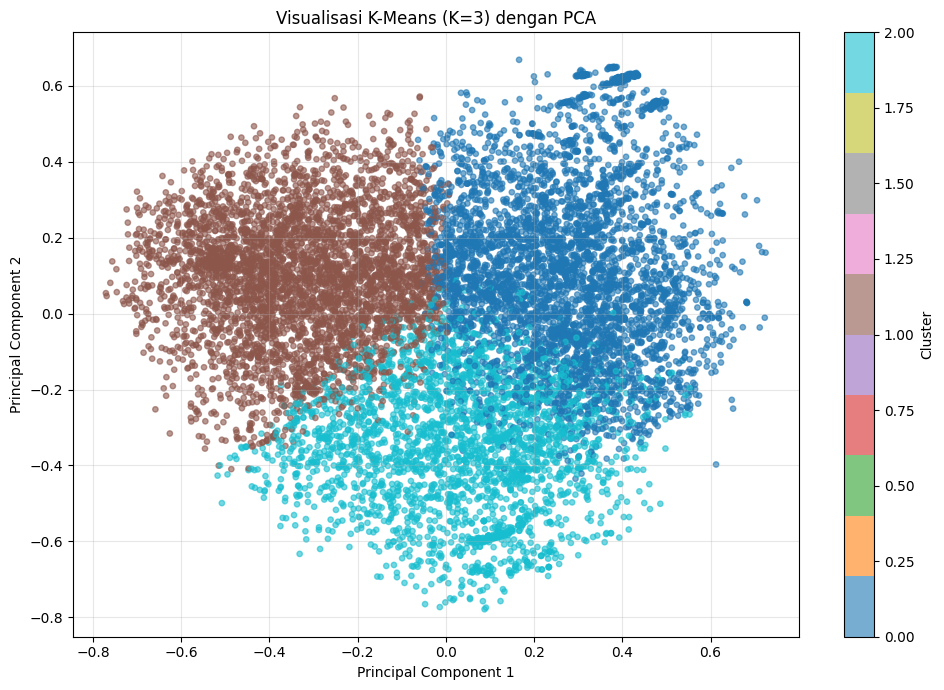

In [56]:
from sklearn.decomposition import PCA

pca_vis = PCA(n_components=2)

X_2d = pca_vis.fit_transform(X_cosine)

print("Explained variance ratio:")
print(pca_vis.explained_variance_ratio_)

print(
    "Total variance 2D:",
    pca_vis.explained_variance_ratio_.sum()
)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=cluster_labels,
    cmap="tab10",
    s=15,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(
    f"Visualisasi K-Means (K={K_OPTIMAL}) "
    "dengan PCA"
)

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [57]:
from sklearn.metrics import silhouette_score

silhouette_cosine = silhouette_score(
    X_cosine,
    cluster_labels,
    metric="cosine"
)

print(
    f"Silhouette Score "
    f"(Cosine) = {silhouette_cosine:.4f}"
)

Silhouette Score (Cosine) = 0.1286


In [58]:
# [TAMBAHAN] Ukur waktu & memori: K-Means (Cosine), fit final pada K_OPTIMAL
def _fit_cosine():
    return KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10).fit_predict(X_cosine)

_, ukur_cosine = ukur_kinerja(_fit_cosine)
print(f"K-Means Cosine | waktu = {ukur_cosine['waktu_detik']:.3f} detik | "
      f"RSS = {ukur_cosine['mem_rss_mib']:.1f} MiB | tracemalloc = {ukur_cosine['mem_tracemalloc_mib']:.1f} MiB")

K-Means Cosine | waktu = 0.853 detik | RSS = 0.0 MiB | tracemalloc = 14.2 MiB


In [59]:
# [TAMBAHAN] simpan hasil K-Means Cosine untuk perbandingan
hasil_cosine = {
    "nama": "K-Means\n(Cosine)",
    "K": K_OPTIMAL,
    "labels": np.array(cluster_labels).copy(),
    "silhouette_native": silhouette_cosine,                        # metric cosine
    "total_cluster": len(np.unique(cluster_labels)),
    **ukur_cosine,                                                 # waktu_detik, mem_rss_mib, mem_tracemalloc_mib
}
print("Tersimpan: K =", hasil_cosine["K"], "| Silhouette =", round(hasil_cosine["silhouette_native"], 4))

Tersimpan: K = 3 | Silhouette = 0.1286


---
# 4. Perbandingan 3 Algoritma (Diagram Batang)

- **Silhouette (metrik masing-masing)**: memakai metrik jaraknya sendiri (Euclidean / Manhattan / Cosine), jadi skalanya tidak persis setara.
- **Silhouette (Euclidean seragam)**: ketiga hasil cluster dinilai dengan satu metrik yang sama pada `X_scaled`, sehingga adil dibandingkan.
- **ARI & NMI**: kecocokan cluster dengan label asli `status` (label tidak dipakai saat clustering).

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score, normalized_mutual_info_score
)

hasil = [hasil_euclid, hasil_manhattan, hasil_cosine]
y_true = df["status"].values

rows = []
for h in hasil:
    rows.append({
        "Algoritma": h["nama"].replace("\n", " "),
        "K": h["K"],
        "Silhouette (metrik masing-masing)": h["silhouette_native"],
        "Silhouette (Euclidean seragam)": silhouette_score(X_scaled, h["labels"], metric="euclidean"),
        "ARI": adjusted_rand_score(y_true, h["labels"]),
        "NMI": normalized_mutual_info_score(y_true, h["labels"]),
    })

df_banding = pd.DataFrame(rows).set_index("Algoritma")
display(df_banding.round(4))


,K,Silhouette (metrik masing-masing),Silhouette (Euclidean seragam),ARI,NMI
Algoritma,,,,,
K-Means (Euclidean),4,0.0785,0.0785,0.3990,0.3557
K-Medians (Manhattan),7,0.0759,0.0167,0.1515,0.2283
K-Means (Cosine),3,0.1286,0.0046,0.3339,0.2831


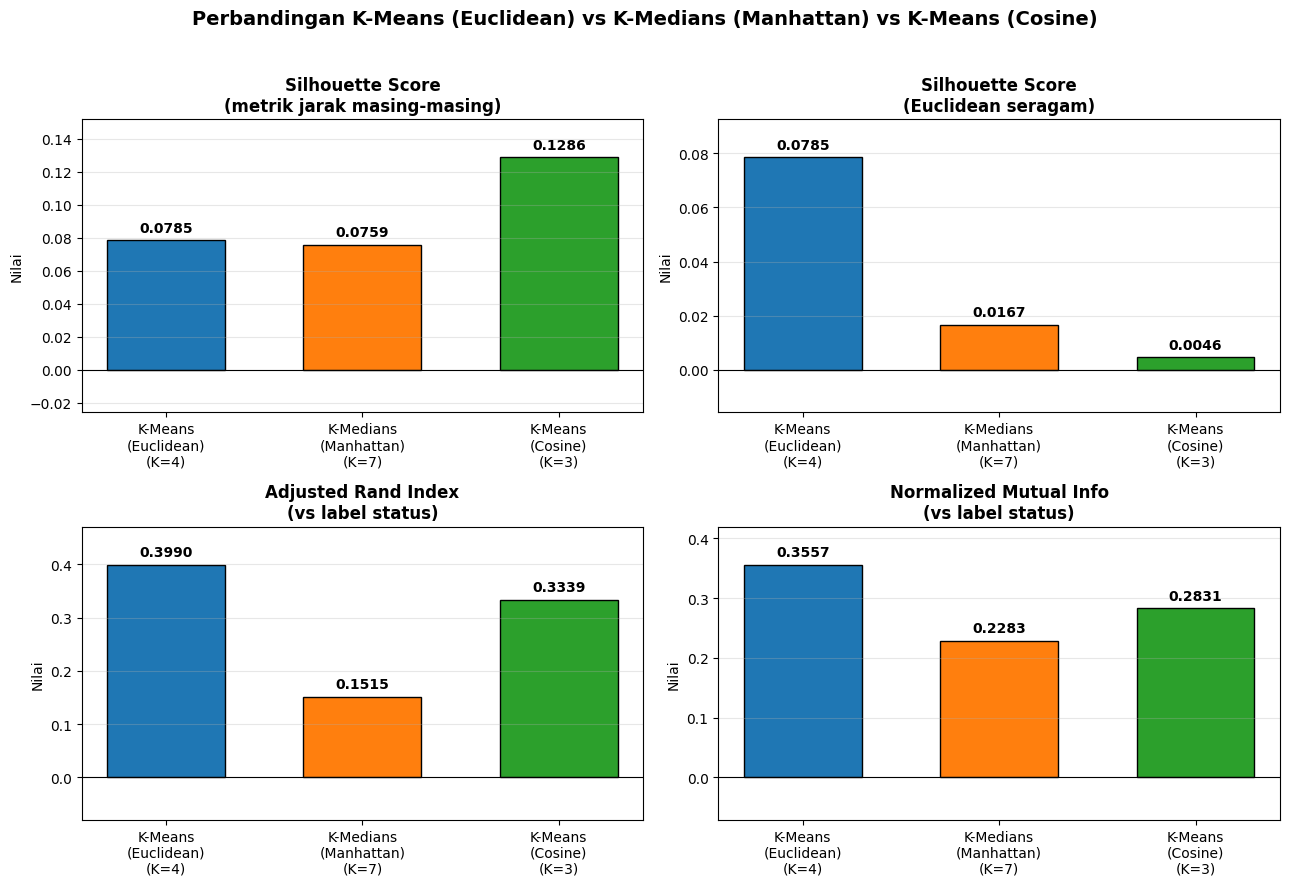

In [61]:
nama = [h["nama"] + f"\n(K={h['K']})" for h in hasil]
warna = ["tab:blue", "tab:orange", "tab:green"]

metrik = [
    ("Silhouette (metrik masing-masing)", "Silhouette Score\n(metrik jarak masing-masing)"),
    ("Silhouette (Euclidean seragam)",    "Silhouette Score\n(Euclidean seragam)"),
    ("ARI",                               "Adjusted Rand Index\n(vs label status)"),
    ("NMI",                               "Normalized Mutual Info\n(vs label status)"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (kolom, judul) in zip(axes.ravel(), metrik):
    nilai = df_banding[kolom].values
    bars = ax.bar(nama, nilai, color=warna, edgecolor="black", width=0.6)
    ax.set_title(judul, fontweight="bold")
    ax.set_ylabel("Nilai")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.grid(axis="y", alpha=0.3)

    batas = max(abs(nilai).max(), 1e-9)
    ax.set_ylim(min(0, nilai.min()) - 0.20 * batas, nilai.max() + 0.18 * batas)
    for b, v in zip(bars, nilai):
        ax.annotate(f"{v:.4f}", (b.get_x() + b.get_width() / 2, v),
                    ha="center", va="bottom" if v >= 0 else "top",
                    xytext=(0, 4 if v >= 0 else -4), textcoords="offset points",
                    fontweight="bold")

fig.suptitle("Perbandingan K-Means (Euclidean) vs K-Medians (Manhattan) vs K-Means (Cosine)",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("perbandingan_3_algoritma.png", dpi=200, bbox_inches="tight")
plt.show()


## Ringkasan: Waktu Komputasi, Memori, Total Cluster, dan Silhouette Score

- **Waktu komputasi**: durasi *fit* final tiap algoritma pada K optimal (tanpa elbow/silhouette sweep).
- **Memori (RSS)**: kenaikan puncak memori proses selama *fit* (termasuk alokasi C/Cython milik scikit-learn).
- **Memori (tracemalloc)**: puncak alokasi Python/NumPy selama *fit*.
- **Total cluster**: jumlah cluster yang benar-benar terbentuk (harus sama dengan K, artinya tidak ada cluster kosong).
- **Silhouette**: memakai metrik jarak masing-masing algoritma.
- Catatan: K-Medians memakai `n_init=20` (sesuai sel final di bagian 2), sedangkan dua K-Means memakai `n_init=10`.

In [62]:
# [TAMBAHAN] Tabel ringkasan kinerja
df_kinerja = pd.DataFrame([{
    "Algoritma": h["nama"].replace("\n", " "),
    "Total Cluster": h["total_cluster"],
    "Silhouette Score": h["silhouette_native"],
    "Waktu Komputasi (detik)": h["waktu_detik"],
    "Memori Puncak RSS (MiB)": h["mem_rss_mib"],
    "Memori Puncak tracemalloc (MiB)": h["mem_tracemalloc_mib"],
} for h in hasil]).set_index("Algoritma")

display(df_kinerja.round(4))

,Total Cluster,Silhouette Score,Waktu Komputasi (detik),Memori Puncak RSS (MiB),Memori Puncak tracemalloc (MiB)
Algoritma,,,,,
K-Means (Euclidean),4,0.0785,1.3624,0.0312,14.1957
K-Medians (Manhattan),7,0.0759,14.1296,4.7344,10.9235
K-Means (Cosine),3,0.1286,0.8530,0.0039,14.1957


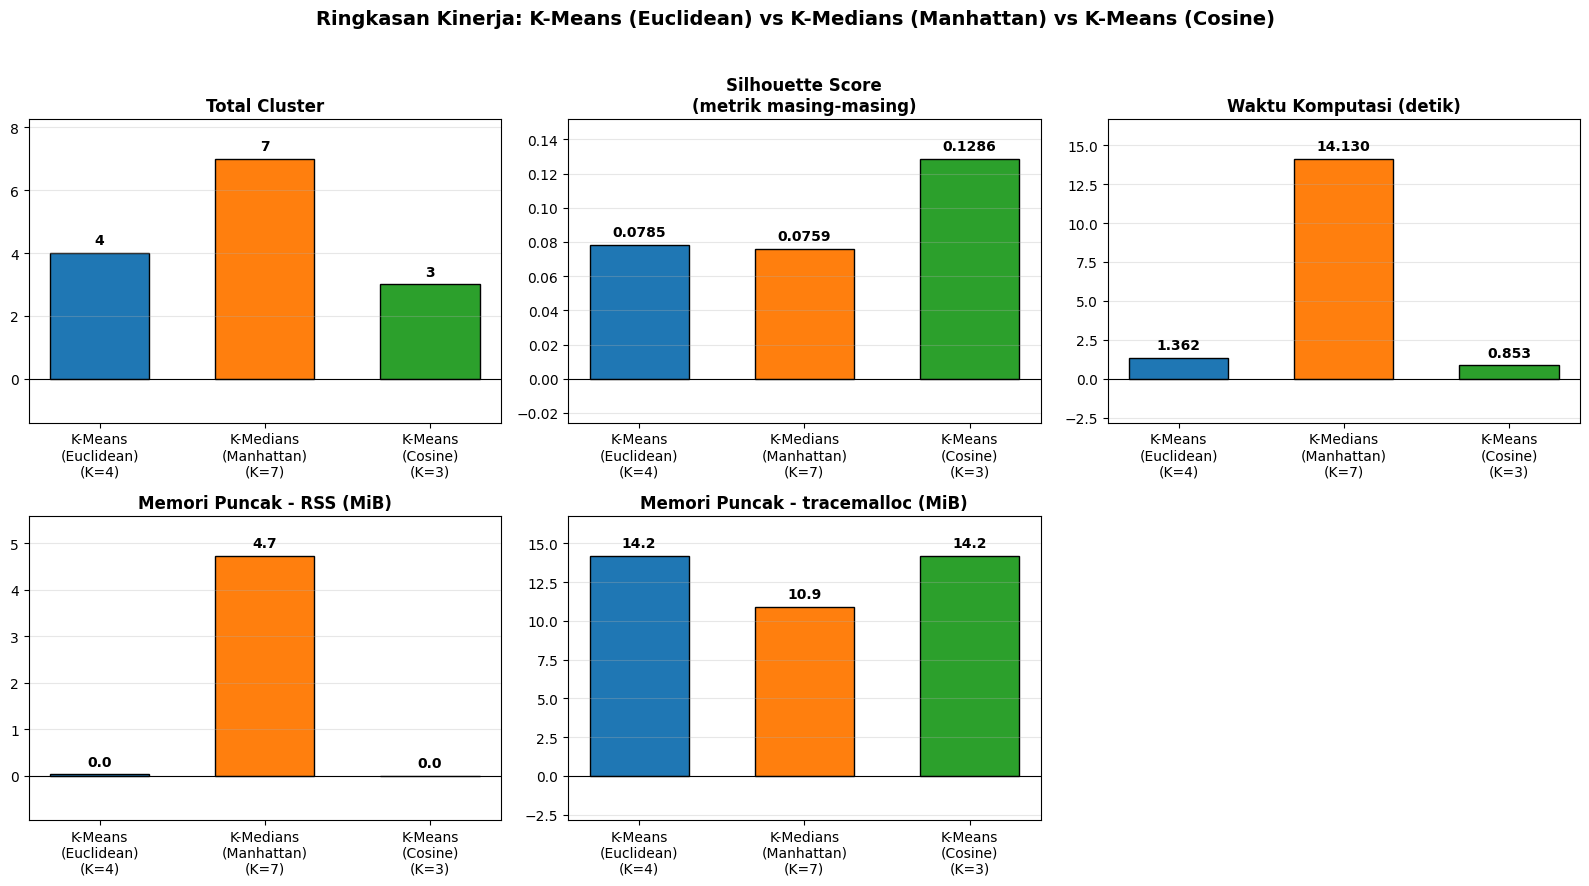

In [63]:
# [TAMBAHAN] Diagram batang: total cluster, silhouette, waktu, dan memori
nama = [h["nama"] + f"\n(K={h['K']})" for h in hasil]
warna = ["tab:blue", "tab:orange", "tab:green"]

panel = [
    ("Total Cluster",                   "Total Cluster",                         "{:.0f}"),
    ("Silhouette Score",                "Silhouette Score\n(metrik masing-masing)", "{:.4f}"),
    ("Waktu Komputasi (detik)",         "Waktu Komputasi (detik)",               "{:.3f}"),
    ("Memori Puncak RSS (MiB)",         "Memori Puncak - RSS (MiB)",             "{:.1f}"),
    ("Memori Puncak tracemalloc (MiB)", "Memori Puncak - tracemalloc (MiB)",     "{:.1f}"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (kolom, judul, fmt) in zip(axes.ravel(), panel):
    nilai = df_kinerja[kolom].values
    bars = ax.bar(nama, nilai, color=warna, edgecolor="black", width=0.6)
    ax.set_title(judul, fontweight="bold")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.grid(axis="y", alpha=0.3)
    batas = max(abs(nilai).max(), 1e-9)
    ax.set_ylim(min(0, nilai.min()) - 0.20 * batas, nilai.max() + 0.18 * batas)
    for b, v in zip(bars, nilai):
        ax.annotate(fmt.format(v), (b.get_x() + b.get_width() / 2, v),
                    ha="center", va="bottom" if v >= 0 else "top",
                    xytext=(0, 4 if v >= 0 else -4), textcoords="offset points",
                    fontweight="bold")
axes.ravel()[-1].axis("off")

fig.suptitle("Ringkasan Kinerja: K-Means (Euclidean) vs K-Medians (Manhattan) vs K-Means (Cosine)",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("ringkasan_kinerja_3_algoritma.png", dpi=200, bbox_inches="tight")
plt.show()